# EDA — Fin Sentiment ETL Dataset

**Research question this project is building toward:** does news sentiment improve short-horizon
stock return prediction beyond price/technical signals alone, and do company fundamentals explain
medium/long-horizon returns?

Before any modeling, this notebook characterizes the three data sources this project has collected
(price + technical indicators, news sentiment, quarterly fundamentals) so modeling choices later are
justified by what the data actually looks like, not assumed.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ.setdefault("POSTGRES_HOST", "localhost")

import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

from src.config import Settings
from src.common.db import get_engine

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)

settings = Settings()
engine = get_engine(settings)
TICKERS = list(settings.tickers)
print(f"{len(TICKERS)} tickers configured: {TICKERS}")


30 tickers configured: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'NFLX', 'AMD', 'ORCL', 'INTC', 'JPM', 'V', 'JNJ', 'XOM', 'PG', 'KO', 'WMT', 'HD', 'DIS', 'BA', 'BTC-USD', 'ETH-USD', '^GSPC', '^DJI', '^IXIC', 'GC=F', 'CL=F', 'EURUSD=X', 'THBUSD=X']


## 1. Price data — coverage and return distribution

In [2]:
price = pd.read_sql(
    text('''
        SELECT a.ticker, p.d, p.close, p.return_1d
        FROM fact_price_daily p
        JOIN dim_asset a ON a.asset_id = p.asset_id
        WHERE a.ticker = ANY(:t)
        ORDER BY a.ticker, p.d
    '''),
    engine, params={"t": TICKERS},
)
coverage = price.groupby("ticker").agg(
    n_rows=("d", "size"), start=("d", "min"), end=("d", "max"),
    missing_close=("close", lambda s: s.isna().sum()),
).sort_values("n_rows", ascending=False)
coverage


,n_rows,start,end,missing_close
ticker,,,,
BTC-USD,3652,2016-07-15,2026-07-14,0
ETH-USD,3169,2017-11-09,2026-07-13,0
EURUSD=X,2601,2016-07-14,2026-07-14,0
THBUSD=X,2601,2016-07-14,2026-07-14,0
AAPL,2512,2016-07-14,2026-07-13,0
MSFT,2512,2016-07-14,2026-07-13,0
CL=F,2512,2016-07-14,2026-07-12,0
GC=F,2512,2016-07-14,2026-07-13,0
TSLA,2512,2016-07-14,2026-07-13,0


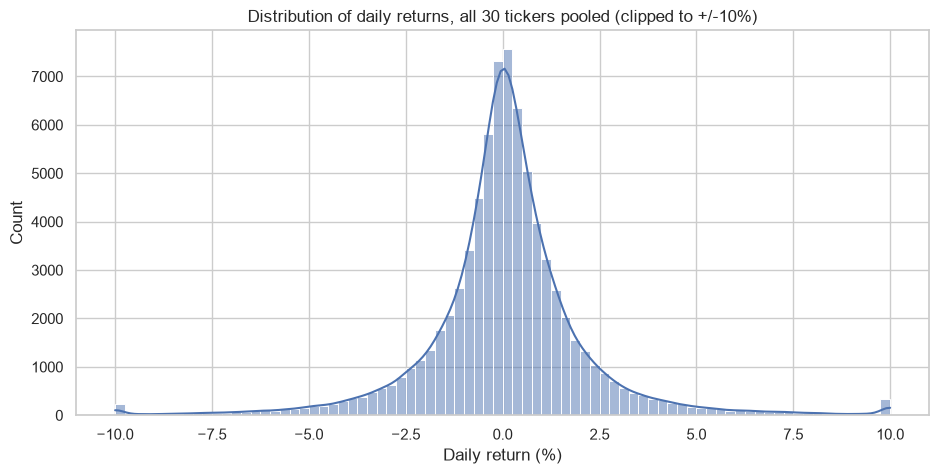

count    77249.000000
mean         0.000836
std          0.025778
min         -3.059661
25%         -0.007246
50%          0.000648
75%          0.008990
max          0.376623
Name: return_1d, dtype: float64

Skew: -22.992   Kurtosis: 2658.509
Kurtosis >> 0 means fat tails vs a normal distribution -- extreme moves are more common
than a naive Gaussian model of returns would predict. Relevant for any model that assumes
normally-distributed errors.


In [3]:
fig, ax = plt.subplots()
sns.histplot(price["return_1d"].clip(-0.1, 0.1) * 100, bins=80, ax=ax, kde=True)
ax.set_title("Distribution of daily returns, all 30 tickers pooled (clipped to +/-10%)")
ax.set_xlabel("Daily return (%)")
plt.show()

print(price["return_1d"].describe())
print(f"\nSkew: {price['return_1d'].skew():.3f}   Kurtosis: {price['return_1d'].kurt():.3f}")
print("Kurtosis >> 0 means fat tails vs a normal distribution -- extreme moves are more common")
print("than a naive Gaussian model of returns would predict. Relevant for any model that assumes")
print("normally-distributed errors.")


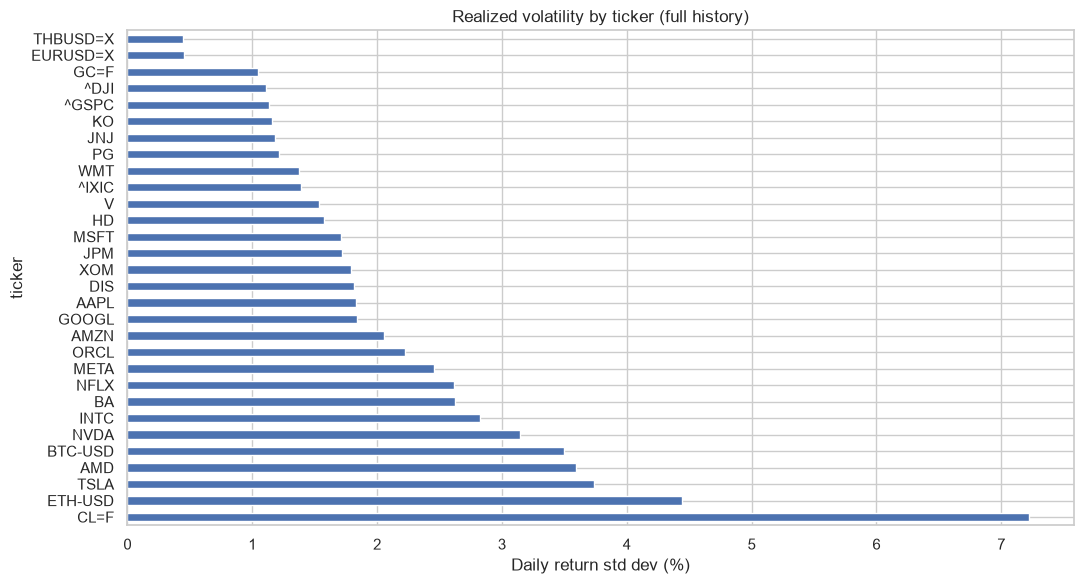

In [4]:
vol_by_ticker = price.groupby("ticker")["return_1d"].std().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(11, 6))
vol_by_ticker.plot(kind="barh", ax=ax)
ax.set_xlabel("Daily return std dev (%)")
ax.set_title("Realized volatility by ticker (full history)")
plt.tight_layout()
plt.show()


**Takeaway:** price coverage is uniform and deep (10 years, all 30 tickers, no meaningful gaps) —
this is the one data source robust enough for rigorous time-series modeling on its own. Returns are
fat-tailed as expected for daily equity/crypto data, which is why the modeling scripts use directional
(classification) targets rather than assuming normally-distributed regression residuals.

## 2. Technical indicators — sanity check and inter-feature correlation

In [5]:
tech = pd.read_sql(
    text('''
        SELECT a.ticker, t.d, t.rsi_14, t.macd_hist, t.volatility_20,
               t.momentum_5, t.momentum_21, t.momentum_63
        FROM fact_technical_daily t
        JOIN dim_asset a ON a.asset_id = t.asset_id
        WHERE a.ticker = ANY(:t)
    '''),
    engine, params={"t": TICKERS},
)
print(f"{len(tech):,} rows, {tech['ticker'].nunique()} tickers")
tech.describe().T


77,301 rows, 30 tickers


,count,mean,std,min,25%,50%,75%,max
rsi_14,76881.0,53.181815,12.490270,9.119231,44.336226,53.172376,62.066877,94.302215
macd_hist,76311.0,-0.017409,90.514108,-2261.493848,-0.419838,0.000054,0.470792,1882.855550
volatility_20,76678.0,0.018430,0.018014,0.001012,0.009060,0.014471,0.023369,0.758063
momentum_5,77151.0,0.004346,0.051834,-2.679161,-0.015945,0.003245,0.023204,0.990275
momentum_21,76671.0,0.018727,0.110962,-2.492070,-0.029462,0.011705,0.056500,2.345654
momentum_63,75411.0,0.058432,0.212633,-2.084507,-0.038946,0.035209,0.120702,3.438891


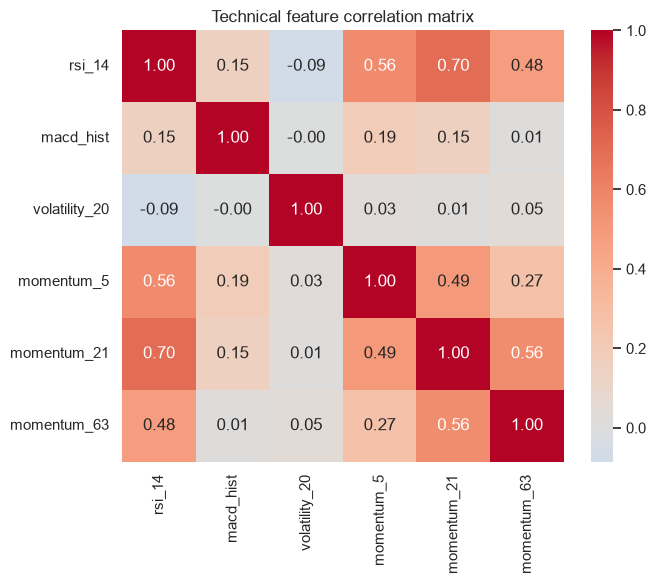

In [6]:
feat_cols = ["rsi_14", "macd_hist", "volatility_20", "momentum_5", "momentum_21", "momentum_63"]
corr = tech[feat_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Technical feature correlation matrix")
plt.tight_layout()
plt.show()


**Takeaway:** RSI-14 is a bounded oscillator (0-100, centered near 50) as expected. The momentum
features at different windows (5/21/63d) are moderately correlated with each other by construction
(they overlap in time) — worth remembering if a linear model's coefficients look unstable, since
correlated features inflate coefficient variance.

## 3. Sentiment data — coverage is the real constraint here

In [7]:
senti = pd.read_sql(
    text('''
        SELECT a.ticker, s.d, s.sentiment_mean, s.news_count
        FROM fact_sentiment_daily s
        JOIN dim_asset a ON a.asset_id = s.asset_id
        WHERE a.ticker = ANY(:t)
        ORDER BY a.ticker, s.d
    '''),
    engine, params={"t": TICKERS},
)
senti_coverage = senti.groupby("ticker").agg(
    n_days=("d", "size"), start=("d", "min"), end=("d", "max"),
    avg_news_per_day=("news_count", "mean"),
).sort_values("n_days", ascending=False)
senti_coverage


,n_days,start,end,avg_news_per_day
ticker,,,,
AAPL,83,2025-12-16,2026-07-13,5.746988
MSFT,83,2025-12-18,2026-07-13,6.987952
TSLA,74,2025-12-16,2026-07-13,6.500000
AMZN,49,2025-12-17,2026-02-27,6.346939
GOOGL,45,2025-12-17,2026-02-27,5.977778
GC=F,22,2026-03-09,2026-06-12,2.636364
BTC-USD,19,2026-03-09,2026-07-10,2.368421
EURUSD=X,10,2026-03-11,2026-07-10,1.800000
THBUSD=X,4,2026-03-11,2026-07-10,1.750000


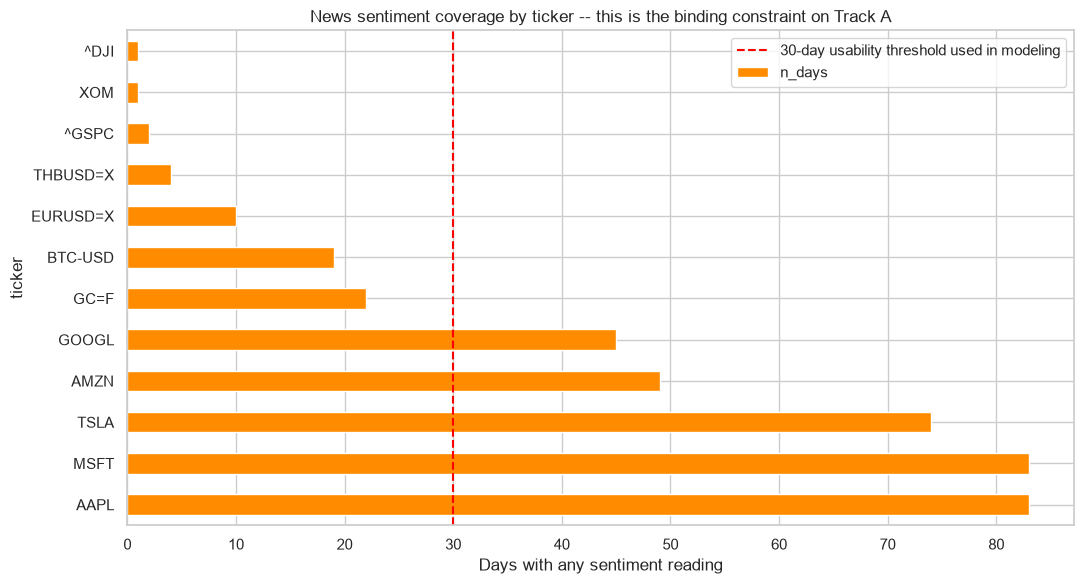

Only 5/30 tickers clear the 30-day usability bar used later in modeling.


In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
senti_coverage["n_days"].plot(kind="barh", ax=ax, color="darkorange")
ax.axvline(30, color="red", linestyle="--", label="30-day usability threshold used in modeling")
ax.set_xlabel("Days with any sentiment reading")
ax.set_title("News sentiment coverage by ticker -- this is the binding constraint on Track A")
ax.legend()
plt.tight_layout()
plt.show()

n_eligible = (senti_coverage["n_days"] >= 30).sum()
print(f"Only {n_eligible}/{len(TICKERS)} tickers clear the 30-day usability bar used later in modeling.")


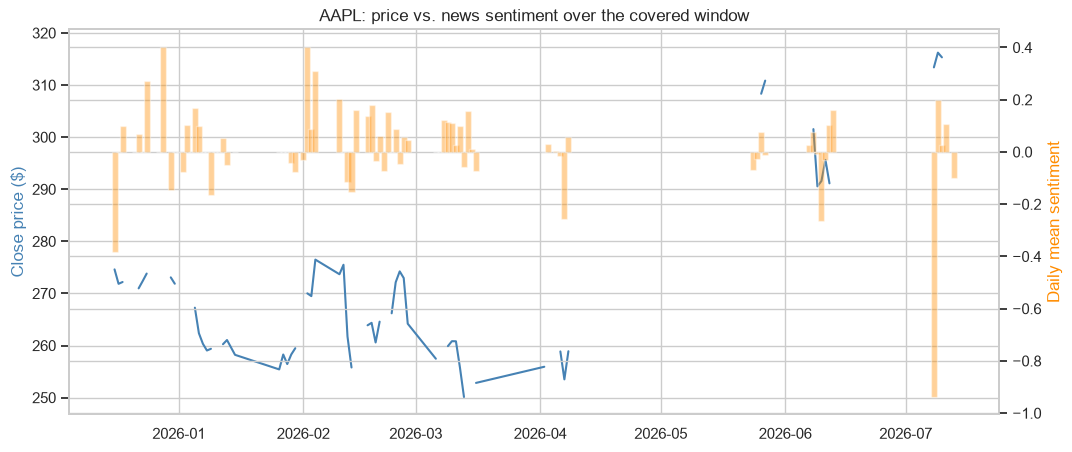

In [9]:
aapl = senti[senti["ticker"] == "AAPL"].merge(
    price[price["ticker"] == "AAPL"][["d", "close"]], on="d", how="left"
).sort_values("d")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(aapl["d"], aapl["close"], color="steelblue", label="Close price")
ax2.bar(aapl["d"], aapl["sentiment_mean"], color="darkorange", alpha=0.4, width=1.5, label="Sentiment")
ax1.set_ylabel("Close price ($)", color="steelblue")
ax2.set_ylabel("Daily mean sentiment", color="darkorange")
ax1.set_title("AAPL: price vs. news sentiment over the covered window")
plt.show()


**Takeaway:** sentiment coverage is real but thin and concentrated in 5 tickers (AAPL, MSFT, TSLA,
AMZN, GOOGL) over roughly Dec 2025 onward — this single fact is *why* Track A's technical+sentiment
experiment runs on ~250 rows instead of the ~77,000-row technical-only dataset, and why those results
were flagged as exploratory rather than conclusive. The automated daily pipeline keeps extending this
window, so re-running this cell in a few months should show materially more coverage.

## 4. Fundamentals — panel shape, not a time series

In [10]:
fund = pd.read_sql(
    text('''
        SELECT a.ticker, f.fiscal_period_end, f.announced_d, f.revenue, f.net_income,
               f.eps_diluted, f.gross_margin, f.net_margin, f.total_debt, f.stockholders_equity
        FROM fact_fundamentals_quarterly f
        JOIN dim_asset a ON a.asset_id = f.asset_id
        ORDER BY a.ticker, f.fiscal_period_end
    '''),
    engine,
)
print(f"{len(fund)} (ticker, quarter) rows across {fund['ticker'].nunique()} stocks")
fund.groupby("ticker").size().sort_values(ascending=False)


106 (ticker, quarter) rows across 21 stocks


ticker
ORCL     6
AAPL     5
META     5
WMT      5
V        5
TSLA     5
PG       5
NVDA     5
NFLX     5
MSFT     5
KO       5
AMD      5
JPM      5
JNJ      5
INTC     5
HD       5
GOOGL    5
DIS      5
BA       5
AMZN     5
XOM      5
dtype: int64

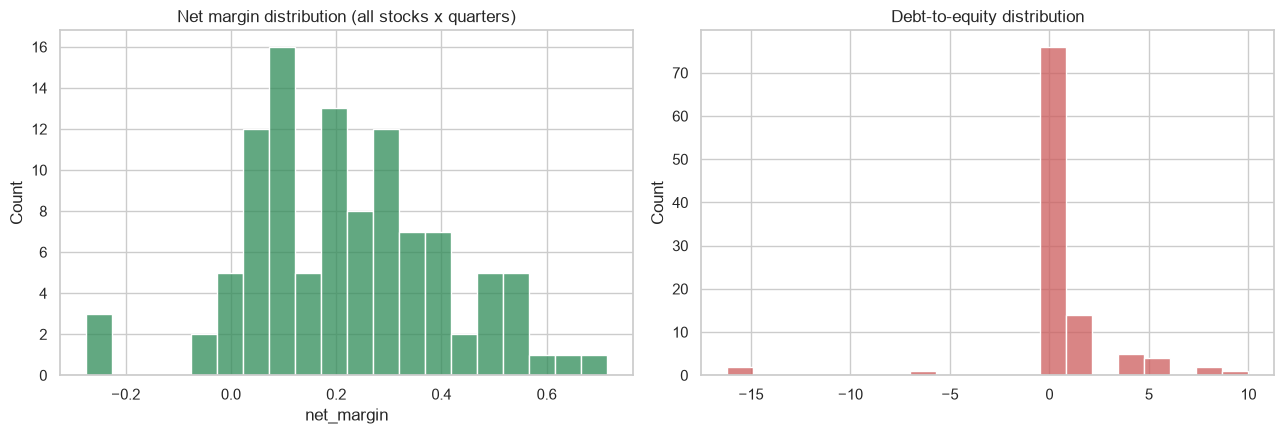

Fiscal periods span 2025-02-28 to 2026-05-31
-- roughly 5 quarters per stock, the free-tier yfinance limit. This panel supports
cross-sectional comparison (many stocks, same era) but NOT a long per-ticker time series.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(fund["net_margin"].dropna(), bins=20, ax=axes[0], color="seagreen")
axes[0].set_title("Net margin distribution (all stocks x quarters)")
sns.histplot((fund["total_debt"] / fund["stockholders_equity"]).replace([np.inf, -np.inf], np.nan).dropna(),
             bins=20, ax=axes[1], color="indianred")
axes[1].set_title("Debt-to-equity distribution")
plt.tight_layout()
plt.show()

print(f"Fiscal periods span {fund['fiscal_period_end'].min()} to {fund['fiscal_period_end'].max()}")
print("-- roughly 5 quarters per stock, the free-tier yfinance limit. This panel supports")
print("cross-sectional comparison (many stocks, same era) but NOT a long per-ticker time series.")


## 5. Feature-vs-forward-return correlation — bridge into modeling

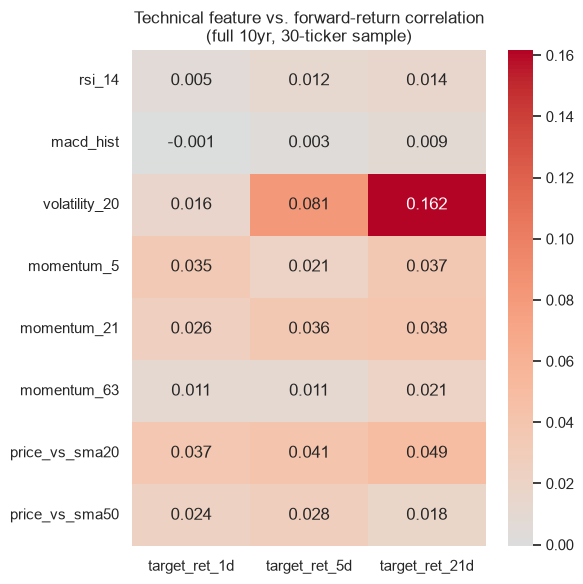

In [12]:
from src.models.dataset import build_technical_dataset, TECHNICAL_FEATURES

ds = build_technical_dataset(engine, TICKERS, horizons=[1, 5, 21])
target_cols = ["target_ret_1d", "target_ret_5d", "target_ret_21d"]
corr_matrix = ds[TECHNICAL_FEATURES + target_cols].corr().loc[TECHNICAL_FEATURES, target_cols]

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Technical feature vs. forward-return correlation\n(full 10yr, 30-ticker sample)")
plt.tight_layout()
plt.show()


**Takeaway:** correlations here are small in absolute terms (mostly under 0.05) even on a huge
sample — consistent with the Track A finding that a simple technical-only classifier could not beat
the majority-class baseline. This EDA cell is a useful sanity check to run *before* training any new
model: if nothing here shows even a weak correlation, a complex model finding "signal" is more likely
overfitting than real structure.

## Summary: what this EDA changes about the modeling plan

1. **Price/technical data (10yr, all 30 tickers)** is deep enough for rigorous walk-forward validation —
   any future model iteration should use it, not a single train/test split.
2. **Sentiment data is the bottleneck**, not the model — only 5 tickers clear a usable coverage bar, and
   even those only go back to Dec 2025. Track A's sentiment results should be re-run periodically as
   this window grows rather than treated as final.
3. **Fundamentals form a cross-sectional panel (~106 rows), not a time series** — confirms the earlier
   decision to use correlation/regression analysis for Track B instead of a classifier, which would
   have overfit badly on this sample size.
4. **Return distributions are fat-tailed**, which is why directional (up/down) targets were used
   throughout rather than raw regression on returns.
